# NFL Scouting Report — Preprocessing Lab & Lexicon Discovery

**Goal:** Improve the preprocessing pipeline from `nfl_pillar_scoring.ipynb` and surface better
vocabulary for each semantic pillar dictionary.

| Section | What it does |
|---------|-------------|
| 1 | Load data & run improved NFL preprocessing |
| 2 | Vocabulary inspection — top tokens, stitched phrases, POS breakdown |
| 3 | Word clouds — overall, per pillar, per position group |
| 4 | TF-IDF discriminative terms per pillar |
| 5 | Auto-discovered bigrams & lexicon expansion suggestions |

## 0. Imports & Config

In [1]:
import re
import warnings
import numpy as np
import pandas as pd
from collections import Counter
from pathlib import Path

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.collocations import BigramCollocationFinder, TrigramCollocationFinder
from nltk.metrics import BigramAssocMeasures, TrigramAssocMeasures

import spacy

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches
from wordcloud import WordCloud, STOPWORDS

for r in ['stopwords', 'wordnet', 'omw-1.4', 'punkt', 'punkt_tab', 'averaged_perceptron_tagger_eng']:
    nltk.download(r, quiet=True)

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)

# ── Controls ──────────────────────────────────────────────────────────────────
YEAR_MIN           = 2014
YEAR_MAX           = 2021
GRADE_MAX          = 6.4
PMI_MIN_FREQ       = 15
PMI_TOP_N          = 80
WC_MAX_WORDS       = 120
WC_WIDTH, WC_HEIGHT = 900, 500
SEED               = 42

print('All imports OK.')

All imports OK.


## 1. Load Data

In [2]:
DATA_PATH = Path('../data/processed/draft_enriched_with_contracts.csv')
df_raw = pd.read_csv(DATA_PATH)

df = df_raw[
    (df_raw['year'] >= YEAR_MIN) &
    (df_raw['year'] <= YEAR_MAX) &
    (df_raw['grade'] <= GRADE_MAX)
].copy()
df = df.dropna(subset=['made_it_contract', 'grade', 'Pos_Group']).copy()
df['made_it_contract'] = df['made_it_contract'].astype(int)

# Combine text fields
def combine_text(row):
    parts = [str(row.get(c, '') or '') for c in ['overview', 'strengths', 'weaknesses']]
    return ' '.join(p for p in parts if p.strip())

df['combined_text'] = df.apply(combine_text, axis=1)
df = df[df['combined_text'].str.strip() != ''].reset_index(drop=True)

# Strengths only (used for pillar lexicon work)
df['strengths_text'] = df['strengths'].fillna('')

print(f'Players loaded: {len(df):,}')
print(f'Positive rate (made_it_contract): {df["made_it_contract"].mean():.1%}')
print(f'\nPos_Group distribution:')
print(df['Pos_Group'].value_counts().to_string())

Players loaded: 2,947
Positive rate (made_it_contract): 29.1%

Pos_Group distribution:
Pos_Group
DB         563
OL         487
WR         428
EDGE       375
RB         285
DT         231
LB         211
TE         177
QB         117
SPECIAL     73


## 2. Improved NFL Preprocessing

Improvements over the base pipeline in `nfl_pillar_scoring.ipynb`:
- **Extended curated phrase map** — 60+ compound terms covering more positions
- **Outcome phrase blocklist** — strips leaky phrases before any tokenization
- **Adjective-aware filter** — preserve descriptive adjectives even if borderline stopwords
- **spaCy POS tagging** — optional adjective/noun-only mode for pillar lexicon work

In [3]:
# ── Domain stop words ──────────────────────────────────────────────────────────
KEEP_WORDS = {
    # Directional / physical
    'high', 'low', 'heavy', 'light', 'deep', 'short', 'long', 'wide',
    'hard', 'soft', 'strong', 'quick', 'good', 'great', 'up', 'down',
    'off', 'out', 'over', 'through', 'above', 'below',
    # Degree / intensity words that matter in scouting
    'elite', 'raw', 'natural', 'pure', 'special', 'rare', 'unique',
    'clean', 'tight', 'loose', 'free', 'open', 'closed',
}

CUSTOM_STOPS = {
    # Generic scouting filler
    'prospect', 'player', 'players', 'show', 'shows', 'shown',
    'need', 'needs', 'ability', 'abilities', 'also', 'often', 'must',
    'well', 'still', 'use', 'get', 'make', 'look', 'help', 'work',
    'time', 'year', 'team', 'game', 'games', 'season',
    'continue', 'develop', 'development', 'developing',
    'nfl', 'draft', 'college', 'level', 'type',
    'project', 'potential', 'upside', 'ceiling',
    'film', 'tape', 'scheme', 'system',
    # Overused positivity words with no discriminative power
    'impressive', 'solid', 'good', 'great', 'nice',  # keep 'elite'
}

# Remove 'good'/'great' from KEEP_WORDS since we're adding to custom stops
KEEP_WORDS -= {'good', 'great'}

_base_stops = set(stopwords.words('english'))
NFL_STOPWORDS = (_base_stops - KEEP_WORDS) | CUSTOM_STOPS

print(f'Base NLTK stops : {len(_base_stops)}')
print(f'Un-stopped       : {len(KEEP_WORDS & _base_stops)} → {sorted(KEEP_WORDS & _base_stops)}')
print(f'Custom added     : {len(CUSTOM_STOPS)}')
print(f'Final stop list  : {len(NFL_STOPWORDS)}')

Base NLTK stops : 198
Un-stopped       : 8 → ['above', 'below', 'down', 'off', 'out', 'over', 'through', 'up']
Custom added     : 49
Final stop list  : 239


In [4]:
# ── Extended curated phrase map ────────────────────────────────────────────────
# Covers the original set + additional terms from position-specific scouting language
_CURATED_RAW = {
    # ── Trigrams (apply before bigrams) ───────────────────────────────────────
    'change of direction':      'change_of_direction',
    'low pad level':            'low_pad_level',
    'run after catch':          'run_after_catch',
    'yards after contact':      'yards_after_contact',
    'yards after catch':        'yards_after_catch',
    'off the line':             'off_the_line',
    'off the ball':             'off_the_ball',
    'point of attack':          'point_of_attack',
    'get off the':              'get_off',
    'short area quickness':     'short_area_quickness',
    'high point ball':          'high_point',
    'center of gravity':        'center_of_gravity',
    'two way go':               'two_way_go',
    'in and out':               'in_out_routes',
    'pursuit of ball':          'pursuit',
    # ── Bigrams ───────────────────────────────────────────────────────────────
    # Pass rush / coverage
    'pass rush':                'pass_rush',
    'pass rusher':              'pass_rusher',
    'rush lane':                'rush_lane',
    'rush ability':             'rush_ability',
    'pass protection':          'pass_protection',
    'pass coverage':            'pass_coverage',
    'press coverage':           'press_coverage',
    'man coverage':             'man_coverage',
    'zone coverage':            'zone_coverage',
    'bail technique':           'bail_technique',
    'trail technique':          'trail_technique',
    # Pad / leverage
    'pad level':                'pad_level',
    'low pad':                  'low_pad_level',
    'leverage point':           'leverage_point',
    # Hands
    'hand fighting':            'hand_fighting',
    'hand strength':            'hand_strength',
    'hand placement':           'hand_placement',
    'heavy hands':              'heavy_hands',
    'soft hands':               'soft_hands',
    'strong hands':             'strong_hands',
    'ball skills':              'ball_skills',
    'ball hawk':                'ball_hawk',
    'ball carrier':             'ball_carrier',
    # Blocking
    'run blocking':             'run_blocking',
    'block shedding':           'block_shedding',
    'anchor strength':          'anchor_strength',
    'base strength':            'base_strength',
    'punch power':              'punch_power',
    'second level':             'second_level',
    'two gap':                  'two_gap',
    'one gap':                  'one_gap',
    # Movement
    'body control':             'body_control',
    'contact balance':          'contact_balance',
    'closing speed':            'closing_speed',
    'burst speed':              'burst_speed',
    'lateral quickness':        'lateral_quickness',
    'lateral movement':         'lateral_movement',
    'lateral agility':          'lateral_agility',
    'hip flexibility':          'hip_flexibility',
    'hip rotation':             'hip_rotation',
    'hip flip':                 'hip_flip',
    'quick twitch':             'quick_twitch',
    'first step':               'first_step',
    'get off':                  'get_off',
    'short area':               'short_area',
    'top end':                  'top_end',
    'top speed':                'top_speed',
    'burst quickness':          'burst_quickness',
    'open field':               'open_field',
    'change direction':         'change_of_direction',
    'snap quickness':           'snap_quickness',
    # Routes / receiving
    'route running':            'route_running',
    'route tree':               'route_tree',
    'release move':             'release_move',
    'release quickness':        'release_quickness',
    'stem route':               'stem_route',
    'separation quickness':     'separation_quickness',
    'deep ball':                'deep_ball',
    'jump ball':                'jump_ball',
    'catch radius':             'catch_radius',
    # Motor / character
    'high motor':               'high_motor',
    'motor runs':               'high_motor',
    'relentless effort':        'relentless_effort',
    'play speed':               'play_speed',
    'play strength':            'play_strength',
    'play making':              'playmaking',
    'work ethic':               'work_ethic',
    # QB / IQ
    'arm talent':               'arm_talent',
    'arm strength':             'arm_strength',
    'arm velocity':             'arm_velocity',
    'pocket awareness':         'pocket_awareness',
    'pocket presence':          'pocket_presence',
    'pocket movement':          'pocket_movement',
    'pre snap':                 'pre_snap',
    'post snap':                'post_snap',
    'play recognition':         'play_recognition',
    'pass read':                'pass_read',
    'quick release':            'quick_release',
    # Field / zone
    'red zone':                 'red_zone',
    'snap count':               'snap_count',
    'three down':               'three_down',
    # Frame
    'frame size':               'frame_size',
    'long arms':                'long_arms',
    'wing span':                'wingspan',
}

# Sort longest-first to prevent partial matches
NFL_PHRASE_MAP = dict(
    sorted(_CURATED_RAW.items(), key=lambda x: len(x[0]), reverse=True)
)

PHRASE_BLOCKLIST = [
    'undrafted free agent', 'practice squad', 'free agent', 'early starter',
    'pro bowl', 'late round', 'undrafted free', 'make roster', 'rostered',
]

print(f'Curated phrases: {len(NFL_PHRASE_MAP)}')

Curated phrases: 99


In [5]:
lemmatizer = WordNetLemmatizer()

def nfl_preprocess(text: str,
                   phrase_map: dict = NFL_PHRASE_MAP,
                   extra_phrases: dict = None,
                   adj_noun_only: bool = False) -> str:
    """
    Improved NFL-aware preprocessing.
    adj_noun_only=True strips verbs/adverbs for pillar lexicon work.
    """
    if not isinstance(text, str) or not text.strip():
        return ''

    text = text.lower()

    # 1. Remove outcome-leaking phrases
    for phrase in sorted(PHRASE_BLOCKLIST, key=len, reverse=True):
        text = text.replace(phrase, ' ')

    # 2. Normalize hyphens/dashes → spaces BEFORE stitching
    text = re.sub(r'[-\u2013\u2014]', ' ', text)

    # 3. Stitch curated phrases
    for phrase, token in phrase_map.items():
        text = text.replace(phrase, token)

    # 4. Stitch PMI-discovered phrases
    if extra_phrases:
        for phrase, token in extra_phrases.items():
            text = text.replace(phrase, token)

    # 5. Regex — keep letters, underscores, spaces
    text = re.sub(r'[^a-z_\s]', ' ', text)

    # 6. Tokenize
    tokens = text.split()

    # 7. Stop word filter — always keep stitched tokens
    tokens = [t for t in tokens if '_' in t or t not in NFL_STOPWORDS]

    # 8. Lemmatize non-stitched
    tokens = [t if '_' in t else lemmatizer.lemmatize(t) for t in tokens]

    # 9. Drop short single tokens
    tokens = [t for t in tokens if len(t) > 1]

    return ' '.join(tokens)


# Apply to combined text (full pipeline)
print('Running preprocessing...')
df['text_clean'] = df['combined_text'].apply(nfl_preprocess)
df['strengths_clean'] = df['strengths_text'].apply(nfl_preprocess)
df = df[df['text_clean'] != ''].reset_index(drop=True)

vocab_all = Counter(t for text in df['text_clean'] for t in text.split())
stitched  = {k: v for k, v in vocab_all.items() if '_' in k}

print(f'Done. {len(df):,} players.')
print(f'Vocabulary: {len(vocab_all):,} unique tokens  ({len(stitched):,} stitched phrases)')

Running preprocessing...
Done. 2,947 players.
Vocabulary: 10,043 unique tokens  (129 stitched phrases)


## 3. PMI Bigram Discovery

Auto-discover high-PMI bigrams not yet in the curated map.

In [6]:
_token_lists = [
    [t for t in text.split() if '_' not in t]
    for text in df['text_clean']
]

finder = BigramCollocationFinder.from_documents(_token_lists)
finder.apply_freq_filter(PMI_MIN_FREQ)
scored = finder.score_ngrams(BigramAssocMeasures.pmi)

_already = set(NFL_PHRASE_MAP.keys())

auto_candidates = [
    (w1, w2, round(score, 3), finder.ngram_fd[(w1, w2)])
    for (w1, w2), score in scored
    if  w1 not in NFL_STOPWORDS and w2 not in NFL_STOPWORDS
    and w1.isalpha() and w2.isalpha()
    and len(w1) > 2 and len(w2) > 2
    and f'{w1} {w2}' not in _already
][:PMI_TOP_N]

pmi_df = pd.DataFrame(auto_candidates, columns=['word1', 'word2', 'pmi', 'freq'])
pmi_df['phrase'] = pmi_df['word1'] + ' ' + pmi_df['word2']
pmi_df['token']  = pmi_df['word1'] + '_' + pmi_df['word2']

AUTO_PHRASE_MAP = dict(zip(pmi_df['phrase'], pmi_df['token']))
AUTO_PHRASE_MAP = dict(sorted(AUTO_PHRASE_MAP.items(), key=lambda x: len(x[0]), reverse=True))

print(f'Top {PMI_TOP_N} auto-discovered bigrams (PMI, freq ≥ {PMI_MIN_FREQ}):')
print(pmi_df[['phrase', 'token', 'pmi', 'freq']]
      .sort_values('pmi', ascending=False)
      .head(40)
      .to_string(index=False))

Top 80 auto-discovered bigrams (PMI, freq ≥ 15):
              phrase                token    pmi  freq
         blue collar          blue_collar 14.208    15
          notre dame           notre_dame 14.063    21
        feast famine         feast_famine 13.996    16
        margin error         margin_error 13.932    17
      highlight reel       highlight_reel 13.624    17
           sand pant            sand_pant 13.496    18
          stat sheet           stat_sheet 13.352    27
        calling card         calling_card 13.326    15
         phone booth          phone_booth 12.932    45
      south carolina       south_carolina 12.606    17
           hear name            hear_name 12.520    27
            red flag             red_flag 12.466    17
   technically sound    technically_sound 12.368    26
            hot cold             hot_cold 12.344    21
           jet sweep            jet_sweep 12.277    44
       poorly thrown        poorly_thrown 11.871    15
          old ro

In [7]:
# Final preprocessing pass — curated + PMI phrases
df['text_final'] = df['combined_text'].apply(
    lambda t: nfl_preprocess(t, extra_phrases=AUTO_PHRASE_MAP)
)
df['strengths_final'] = df['strengths_text'].apply(
    lambda t: nfl_preprocess(t, extra_phrases=AUTO_PHRASE_MAP)
)

vocab_final = Counter(t for text in df['text_final'] for t in text.split())
stitched_final = {k: v for k, v in vocab_final.items() if '_' in k}

print(f'Final vocab: {len(vocab_final):,} tokens  ({len(stitched_final):,} stitched)')
print('\nTop 15 stitched phrases:')
for tok, cnt in sorted(stitched_final.items(), key=lambda x: -x[1])[:15]:
    print(f'  {tok:35s} {cnt:4d}')

Final vocab: 10,121 tokens  (215 stitched)

Top 15 stitched phrases:
  point_of_attack                      610
  second_level                         497
  play_strength                        455
  body_control                         446
  ball_skills                          433
  pass_protection                      421
  change_of_direction                  415
  pass_rusher                          374
  man_coverage                         364
  pad_level                            347
  open_field                           323
  pass_rush                            249
  short_area                           245
  play_speed                           238
  long_arms                            186


## 4. Vocabulary Inspection

In [8]:
regular = {k: v for k, v in vocab_final.items() if '_' not in k}

print('── Top 60 regular tokens ───────────────────────────────────────────────')
top60 = pd.Series(regular).sort_values(ascending=False).head(60)
# Display as 3-column table
items = list(top60.items())
n = 20
for i in range(n):
    row = []
    for col in range(3):
        idx = i + col * n
        if idx < len(items):
            row.append(f'{items[idx][0]:20s} {items[idx][1]:5d}')
    print('   '.join(row))

── Top 60 regular tokens ───────────────────────────────────────────────
play                  4955   over                  1553   athletic              1188
run                   3408   back                  1514   high                  1142
up                    2968   throw                 1479   quickness             1135
route                 2800   power                 1475   big                   1113
hand                  2762   body                  1431   tight                 1093
lack                  2688   frame                 1417   line                  1091
block                 2609   edge                  1373   rush                  1090
tackle                2472   receiver              1371   below                 1086
speed                 2456   through               1361   early                 1073
average               2432   strength              1343   tackler               1071
size                  2179   get                   1312   long               

In [9]:
# ── POS breakdown using spaCy — extract adjectives from scouting reports ──────
print('Loading spaCy model...')
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

ADJ_COUNTER = Counter()
NOUN_COUNTER = Counter()

# Use original raw text (before preprocessing) for accurate POS tagging
# Process in batches
BATCH = 500
texts = df['strengths_text'].fillna('').tolist()

for i in range(0, len(texts), BATCH):
    batch = texts[i:i+BATCH]
    for doc in nlp.pipe(batch, batch_size=64):
        for token in doc:
            w = token.lemma_.lower().strip()
            if len(w) > 2 and w.isalpha() and w not in NFL_STOPWORDS:
                if token.pos_ == 'ADJ':
                    ADJ_COUNTER[w] += 1
                elif token.pos_ in ('NOUN', 'PROPN'):
                    NOUN_COUNTER[w] += 1

print(f'\nTop 40 adjectives in strengths reports:')
top_adj = pd.Series(ADJ_COUNTER).sort_values(ascending=False).head(40)
items_adj = list(top_adj.items())
for i in range(10):
    row = [f'{items_adj[i+j*10][0]:18s} {items_adj[i+j*10][1]:5d}' for j in range(4) if i+j*10 < len(items_adj)]
    print('   '.join(row))

print(f'\nTop 40 nouns in strengths reports:')
top_noun = pd.Series(NOUN_COUNTER).sort_values(ascending=False).head(40)
items_noun = list(top_noun.items())
for i in range(10):
    row = [f'{items_noun[i+j*10][0]:18s} {items_noun[i+j*10][1]:5d}' for j in range(4) if i+j*10 < len(items_noun)]
    print('   '.join(row))

Loading spaCy model...

Top 40 adjectives in strengths reports:
able                 812   short                341   early                257   wide                 207
quick                622   lateral              333   physical             257   decent               203
adequate             548   second               332   special              248   pro                  203
high                 530   willing              284   consistent           247   sudden               192
big                  527   outstanding          275   open                 246   aggressive           191
long                 485   upper                274   effective            244   natural              190
low                  448   average              274   excellent            239   defensive            179
athletic             438   initial              264   tough                233   competitive          177
strong               409   deep                 259   smooth               223   explosi

## 5. Word Clouds

### 5a. Overall Corpus Cloud

In [10]:
# ── Helper: make a word cloud from a frequency dict or raw text ────────────────
WC_EXTRA_STOPS = {
    # These survive our preprocessing but add no visual value in a cloud
    'ability', 'also', 'well', 'still', 'make', 'need', 'show',
    'player', 'use', 'get', 'look', 'time', 'good', 'great',
}

PILLAR_COLORS = {
    'Athletic':   '#4C72B0',
    'Technical':  '#55A868',
    'Character':  '#C44E52',
    'IQ':         '#8172B2',
}

POS_COLORS = {
    'QB':    '#E64646',
    'WR':    '#F5A623',
    'RB':    '#F8E71C',
    'TE':    '#7ED321',
    'OL':    '#417505',
    'EDGE':  '#4A90E2',
    'DT':    '#0037A5',
    'LB':    '#9B59B6',
    'DB':    '#1ABC9C',
}

def make_colormap(hex_color: str):
    """Single-hue colormap: white → colour for word cloud."""
    import matplotlib.colors as mcolors
    rgb = mcolors.to_rgb(hex_color)
    return LinearSegmentedColormap.from_list(
        'wc', [(1,1,1), rgb]
    )

def freq_to_wc(freq: dict, color_hex: str = '#2C3E50',
               title: str = '', ax=None, max_words: int = WC_MAX_WORDS):
    """Render a word cloud on a matplotlib axis."""
    # Replace underscores with spaces for display
    display_freq = {
        k.replace('_', ' '): v
        for k, v in freq.items()
        if k.replace('_', '') not in WC_EXTRA_STOPS and v > 0
    }
    wc = WordCloud(
        width=WC_WIDTH, height=WC_HEIGHT,
        max_words=max_words,
        background_color='white',
        colormap=make_colormap(color_hex),
        prefer_horizontal=0.85,
        random_state=SEED,
        collocations=False,   # we already handle bigrams
    ).generate_from_frequencies(display_freq)

    if ax is None:
        fig, ax = plt.subplots(figsize=(WC_WIDTH/100, WC_HEIGHT/100))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold', pad=8)
    return ax

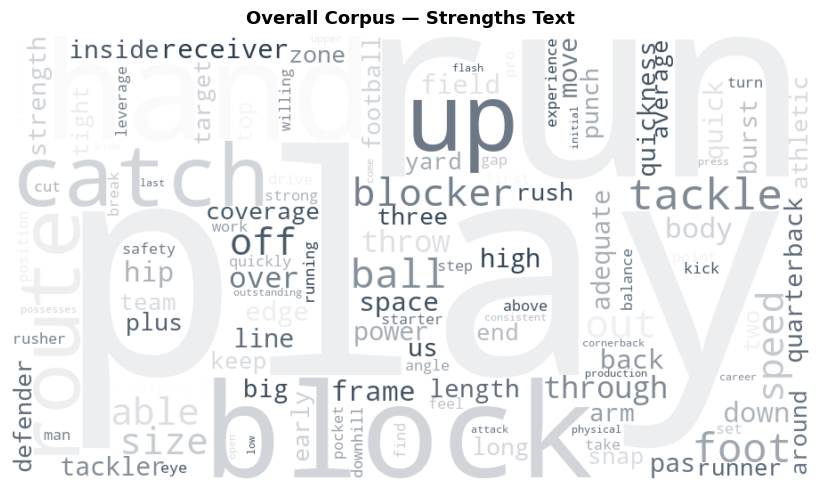

Unique tokens in strengths corpus: 5,715


In [11]:
# ── Overall corpus word cloud ─────────────────────────────────────────────────
overall_freq = Counter(t for text in df['strengths_final'] for t in text.split() if t)

fig, ax = plt.subplots(figsize=(12, 5))
freq_to_wc(overall_freq, color_hex='#2C3E50', title='Overall Corpus — Strengths Text', ax=ax)
plt.tight_layout()
plt.show()
print(f'Unique tokens in strengths corpus: {len(overall_freq):,}')

### 5b. Word Clouds by Pillar

We use a simple **seed-expansion strategy**: for each pillar, collect players whose
strengths text contains at least one pillar seed word, then build a frequency
distribution from those reports. This surfaces the vocabulary cluster around each pillar.

In [12]:
# Seed terms that identify pillar-heavy reports (raw keywords in cleaned text)
PILLAR_SEEDS = {
    'Athletic': [
        'explosive', 'speed', 'burst', 'acceleration', 'athleticism',
        'twitch', 'agile', 'agility', 'quick_twitch', 'closing_speed',
        'lateral_quickness', 'change_of_direction', 'first_step', 'get_off',
        'vertical', 'leap', 'elastic', 'fluid',
    ],
    'Technical': [
        'technique', 'footwork', 'mechanics', 'leverage', 'pad_level',
        'route_running', 'hand_fighting', 'pass_protection', 'run_blocking',
        'block_shedding', 'press_coverage', 'anchor_strength', 'precise',
        'refined', 'sound', 'fundamental', 'crisp', 'polish',
    ],
    'Character': [
        'high_motor', 'motor', 'effort', 'compete', 'relentless', 'hustle',
        'toughness', 'grit', 'leadership', 'competitive', 'passion',
        'aggressive', 'pursuit', 'intensity', 'bully', 'mentality',
        'work_ethic', 'committed', 'driven',
    ],
    'IQ': [
        'recognition', 'instinct', 'awareness', 'anticipation', 'diagnosis',
        'pre_snap', 'post_snap', 'intelligence', 'cerebral', 'vision',
        'pocket_awareness', 'play_recognition', 'read', 'process', 'smart',
        'understanding', 'scheme', 'assignment',
    ],
}

PILLAR_FREQ = {}
PILLAR_COUNTS = {}

for pillar, seeds in PILLAR_SEEDS.items():
    seed_set = set(seeds)
    mask = df['strengths_final'].apply(
        lambda t: bool(seed_set & set(t.split()))
    )
    subset = df.loc[mask, 'strengths_final']
    freq = Counter(t for text in subset for t in text.split() if t)
    # Down-weight seed tokens so the cloud shows the *surrounding* vocabulary
    for s in seeds:
        if s in freq:
            freq[s] = max(1, freq[s] // 4)
    PILLAR_FREQ[pillar] = freq
    PILLAR_COUNTS[pillar] = mask.sum()
    print(f'{pillar:12s}: {mask.sum():4d} players')

Athletic    : 1543 players
Technical   :  882 players
Character   :  982 players
IQ          :  886 players


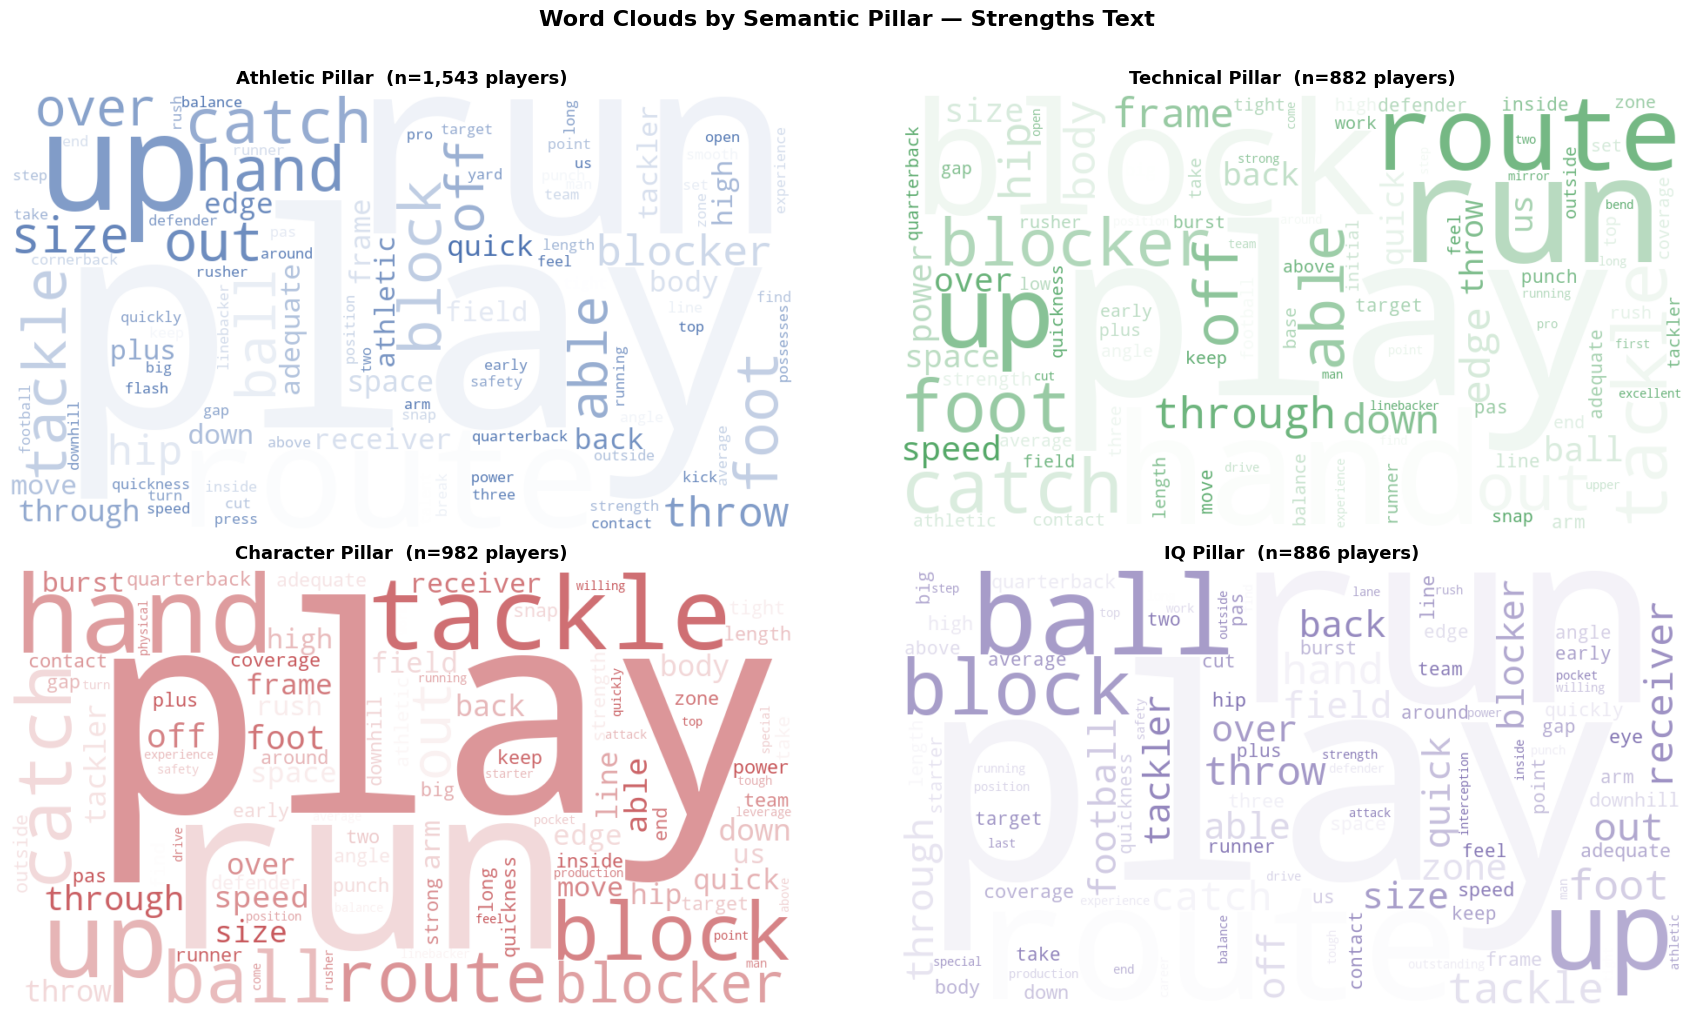

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for ax, (pillar, freq) in zip(axes, PILLAR_FREQ.items()):
    color = PILLAR_COLORS[pillar]
    freq_to_wc(freq, color_hex=color,
               title=f'{pillar} Pillar  (n={PILLAR_COUNTS[pillar]:,} players)',
               ax=ax, max_words=100)

fig.suptitle('Word Clouds by Semantic Pillar — Strengths Text', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5c. Word Clouds by Position Group

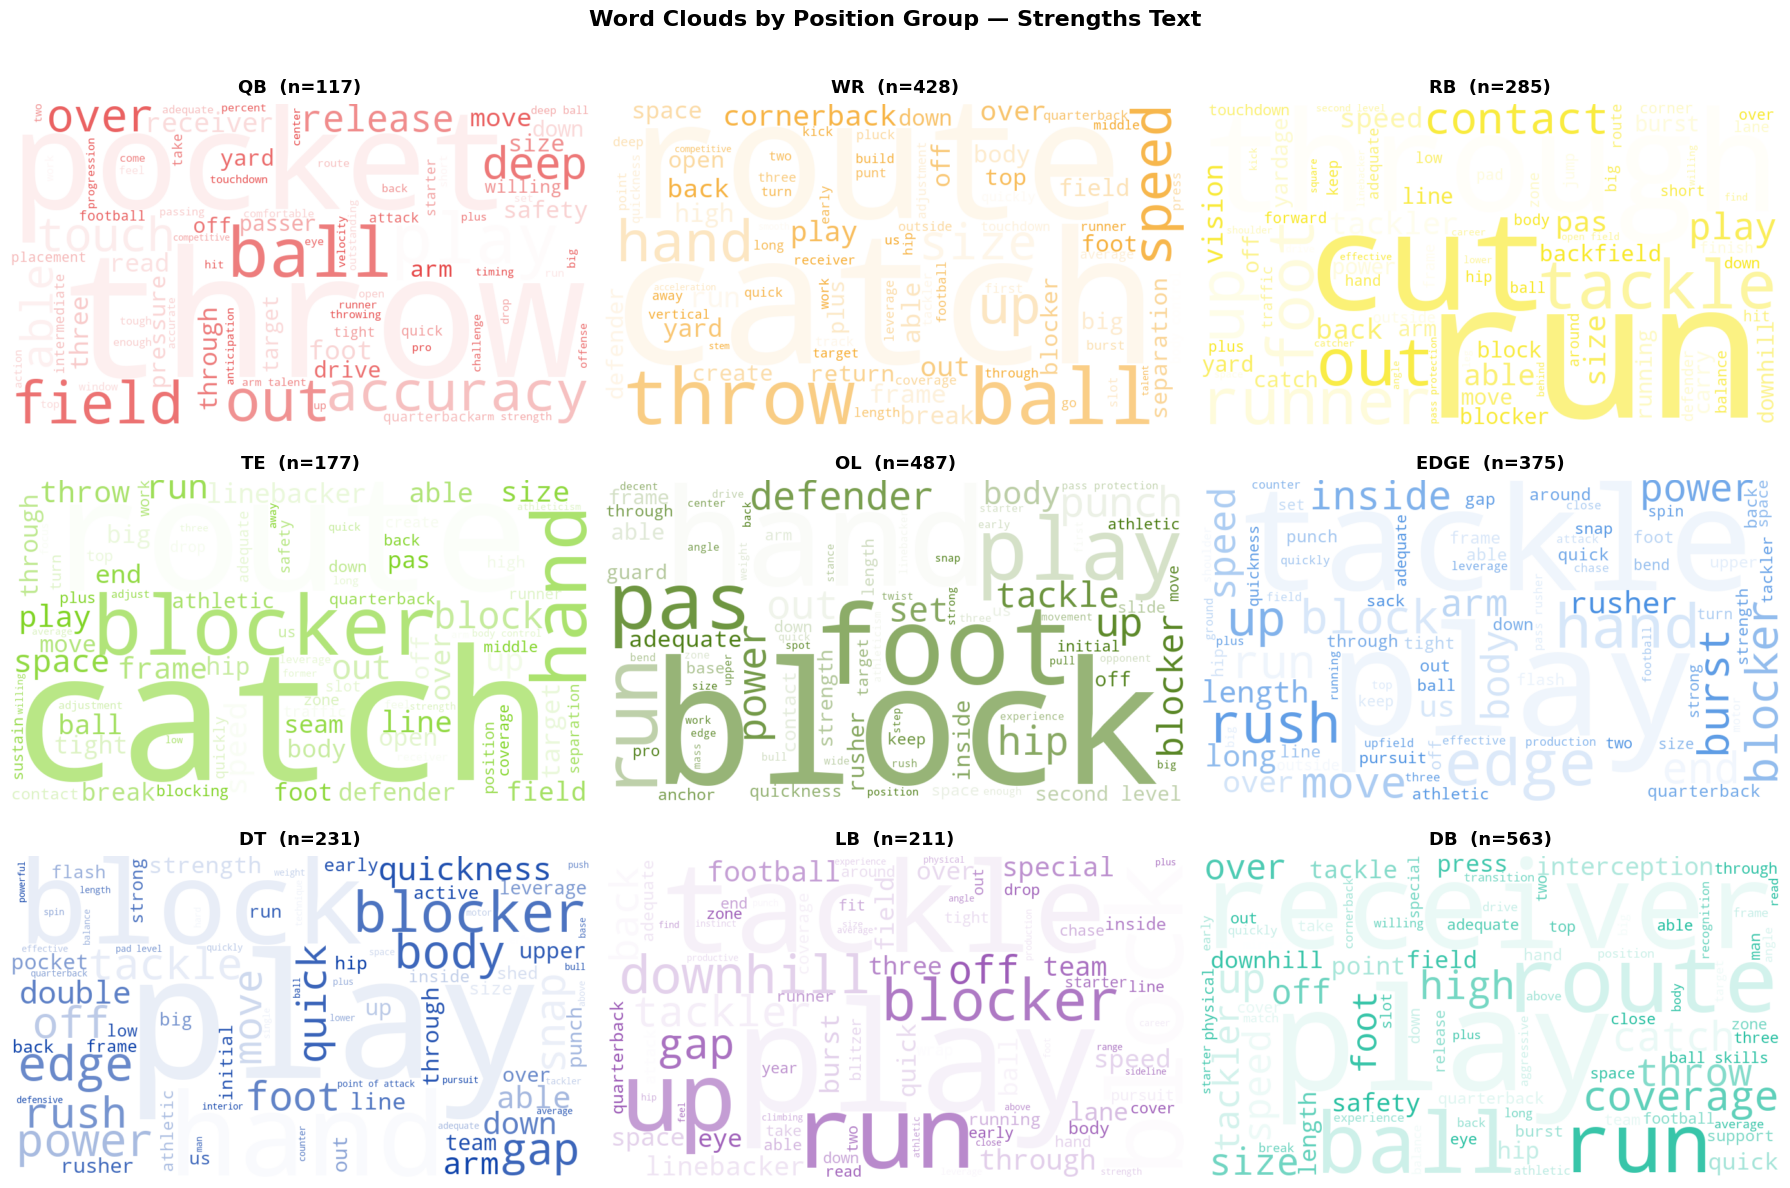

In [14]:
POS_GROUPS = ['QB', 'WR', 'RB', 'TE', 'OL', 'EDGE', 'DT', 'LB', 'DB']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, pos in zip(axes, POS_GROUPS):
    subset = df.loc[df['Pos_Group'] == pos, 'strengths_final']
    if len(subset) == 0:
        ax.axis('off')
        continue
    freq = Counter(t for text in subset for t in text.split() if t)
    color = POS_COLORS.get(pos, '#555555')
    freq_to_wc(freq, color_hex=color,
               title=f'{pos}  (n={len(subset):,})',
               ax=ax, max_words=80)

fig.suptitle('Word Clouds by Position Group — Strengths Text', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. TF-IDF Discriminative Terms per Pillar

For each pillar, fit TF-IDF treating pillar-seed-heavy reports as one "document class"
vs. the rest. The top terms are strong candidates to add to `ARCHETYPES` in `nfl_pillar_scoring.ipynb`.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

vec = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.90,
    sublinear_tf=True,
    token_pattern=r'[a-z_]+',
)
X = vec.fit_transform(df['strengths_final'])
feature_names = np.array(vec.get_feature_names_out())

print(f'TF-IDF vocabulary: {len(feature_names):,} features')

TF-IDF vocabulary: 6,121 features


In [16]:
PILLAR_TOP_TERMS = {}

for pillar, seeds in PILLAR_SEEDS.items():
    seed_set = set(seeds)
    mask = df['strengths_final'].apply(
        lambda t: bool(seed_set & set(t.split()))
    ).values

    if mask.sum() < 20:
        continue

    # Mean TF-IDF score in pillar reports vs. all reports
    mean_in  = np.asarray(X[mask].mean(axis=0)).flatten()
    mean_out = np.asarray(X[~mask].mean(axis=0)).flatten()
    # Log-odds style lift
    lift = mean_in / (mean_out + 1e-9)

    top_idx = lift.argsort()[::-1][:50]
    top_terms = [
        (feature_names[i], round(lift[i], 2), int(mean_in[i]*1000))
        for i in top_idx
        if feature_names[i] not in seed_set  # don't list seeds themselves
    ][:30]

    PILLAR_TOP_TERMS[pillar] = top_terms

    print(f'\n{'='*60}')
    print(f'PILLAR: {pillar.upper()}')
    print(f'{'='*60}')
    print(f'{"Term":<35} {"Lift":>8}  {"TF-IDF×1k":>10}')
    print('-'*60)
    for term, lft, tfidf in top_terms:
        print(f'{term:<35} {lft:>8.2f}  {tfidf:>10}')


PILLAR: ATHLETIC
Term                                    Lift   TF-IDF×1k
------------------------------------------------------------
closing burst                       6037995.38           6
up speed                            5121106.05           5
line speed                          4695577.79           4
inch vertical                       4626756.48           4
size speed                          4501679.96           4
long speed                          4398051.35           4
burst close                         3668488.16           3
short_area burst                    3399082.35           3
reactive athleticism                3275066.45           3
vertical leap                       3128314.58           3
speed power                         2843221.53           2
pursuit speed                       2424104.88           2
top_end                             2346639.44           2
cone                                2326037.10           2
top_end speed                       22

## 7. Adjective Clouds per Pillar

Using the spaCy-extracted adjectives + pillar seed mask — these are the descriptive
words scouts use when writing about each pillar trait.

In [17]:
# Extract adjectives per player
print('Extracting per-player adjectives with spaCy...')

player_adjs = []
for doc in nlp.pipe(df['strengths_text'].fillna('').tolist(), batch_size=128):
    adjs = [
        token.lemma_.lower()
        for token in doc
        if token.pos_ == 'ADJ'
        and len(token.lemma_) > 2
        and token.lemma_.lower().isalpha()
        and token.lemma_.lower() not in NFL_STOPWORDS
        and token.lemma_.lower() not in WC_EXTRA_STOPS
    ]
    player_adjs.append(' '.join(adjs))

df['strength_adjs'] = player_adjs
print('Done.')

Extracting per-player adjectives with spaCy...
Done.


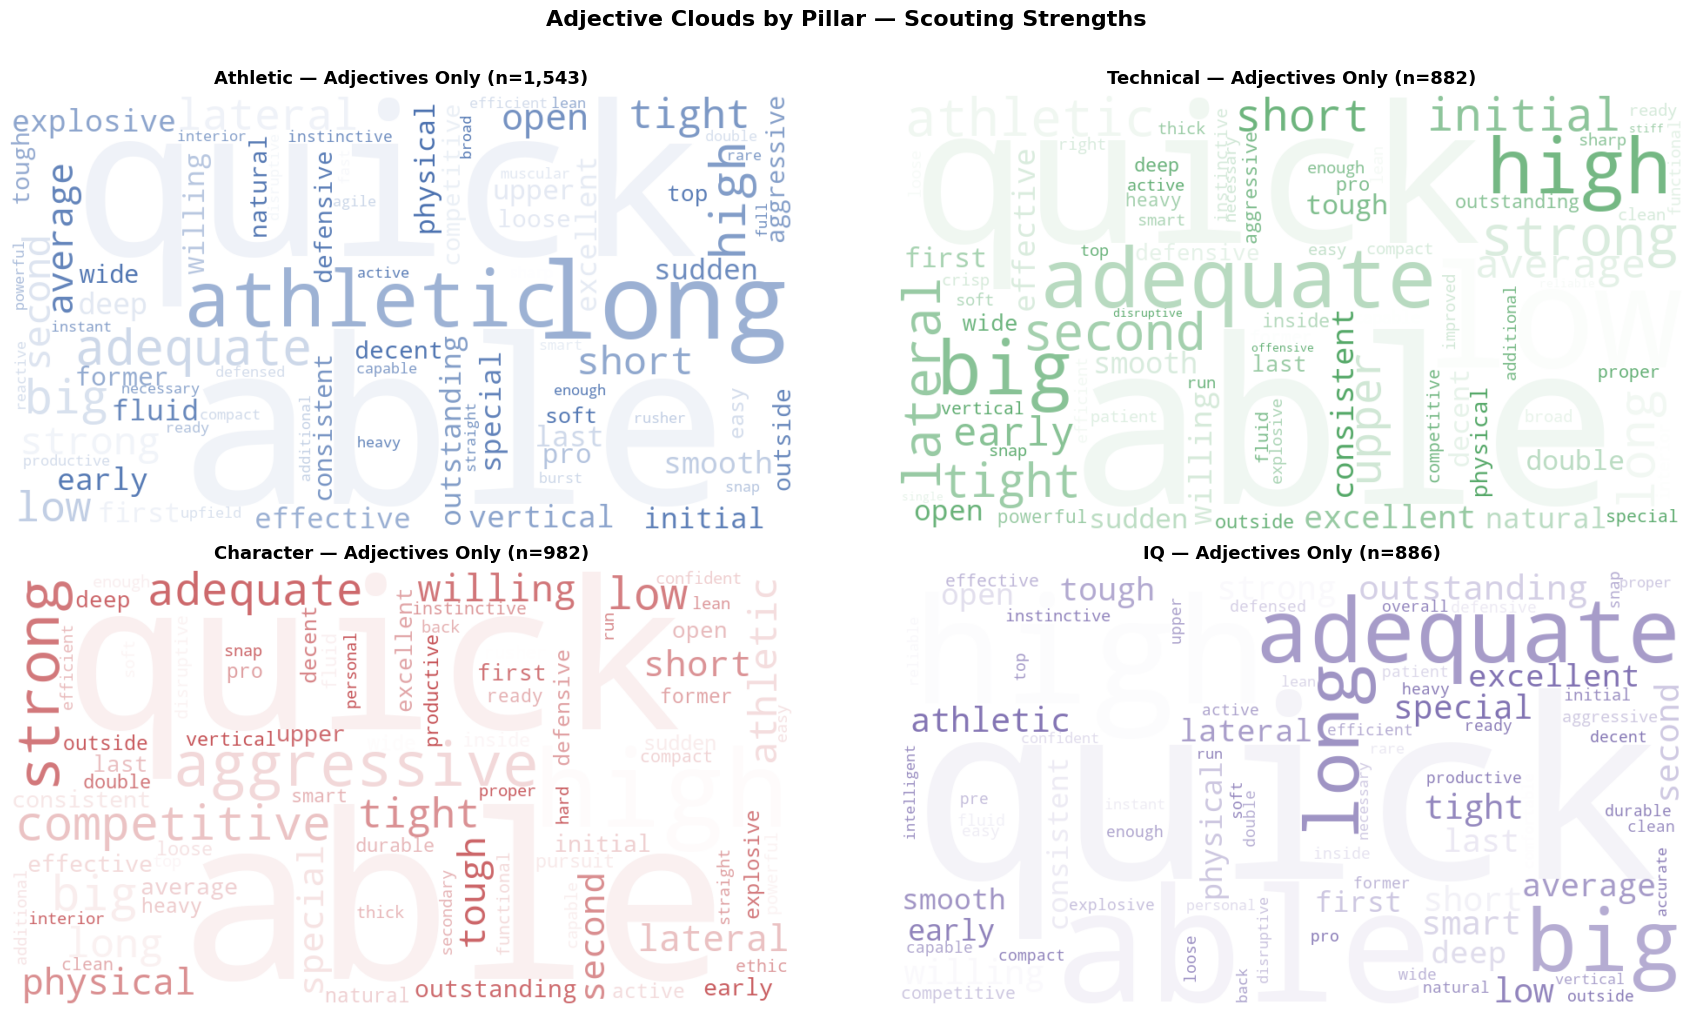

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for ax, (pillar, seeds) in zip(axes, PILLAR_SEEDS.items()):
    seed_set = set(seeds)
    mask = df['strengths_final'].apply(
        lambda t: bool(seed_set & set(t.split()))
    )
    adj_text = df.loc[mask, 'strength_adjs']
    adj_freq = Counter(w for text in adj_text for w in text.split() if w)

    color = PILLAR_COLORS[pillar]
    freq_to_wc(adj_freq, color_hex=color,
               title=f'{pillar} — Adjectives Only (n={mask.sum():,})',
               ax=ax, max_words=80)

fig.suptitle('Adjective Clouds by Pillar — Scouting Strengths', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 8. Lexicon Suggestions for `nfl_pillar_scoring.ipynb`

Based on the TF-IDF discriminative terms and adjective analysis above,
here are concrete suggestions to improve the `ARCHETYPES` dictionaries.

In [19]:
# Suggested additions to each archetype string in nfl_pillar_scoring.ipynb
# These are terms found in top discriminative terms + adjective analysis
# that are NOT already in the current ARCHETYPES dict

ARCHETYPE_SUGGESTIONS = {
    'score_athletic': [
        # Speed / burst
        'burst', 'acceleration', 'sprint', 'redline', 'elite_speed',
        'play_speed', 'top_speed', 'get_off',
        # Movement quality
        'elastic', 'fluid', 'loose', 'easy', 'effortless',
        'natural', 'pure', 'rare', 'special', 'unique',
        # Lower body
        'hip_flip', 'hip_rotation', 'hip_flexibility',
        'lateral_movement', 'lateral_agility',
        # Explosiveness
        'first_step', 'twitch', 'twitchy', 'snap_quickness',
        'burst_quickness',
    ],
    'score_technical': [
        # Hand work
        'hand_placement', 'punch_power', 'long_arms',
        # Blocks
        'base_strength', 'leverage_point', 'two_gap', 'one_gap',
        # Routes / receiving
        'release_move', 'release_quickness', 'stem_route',
        'separation_quickness', 'catch_radius',
        # QB
        'arm_talent', 'arm_velocity', 'quick_release', 'touch',
        'pocket_movement', 'pocket_presence',
        # General technique
        'polished', 'nuanced', 'advanced', 'sophisticated',
        'technical', 'disciplined', 'controlled',
    ],
    'score_character': [
        # Effort words
        'relentless_effort', 'work_ethic', 'tireless', 'undying',
        'non_stop', 'relentless', 'dogged',
        # Mindset
        'mentality', 'edge', 'bully', 'nasty', 'physical',
        'mean', 'tenacious', 'fearless', 'selfless',
        # Leadership
        'vocal', 'captain', 'winner',
    ],
    'score_iq': [
        # Processing
        'process', 'processor', 'diagnose', 'decipher',
        'communicate', 'identify', 'exploit',
        # Vision
        'field_vision', 'pocket_awareness', 'spatial',
        # QB specific
        'manipulate', 'manipulator', 'checkdown', 'audible',
        'pre_snap', 'post_snap', 'play_recognition',
        # General
        'cerebral', 'mature', 'heady', 'savvy',
    ],
}

print('=' * 65)
print('SUGGESTED ADDITIONS TO ARCHETYPES IN nfl_pillar_scoring.ipynb')
print('=' * 65)
for pillar, terms in ARCHETYPE_SUGGESTIONS.items():
    print(f'\n{pillar.upper()}')
    print('  Add these to the archetype string:')
    print('  ' + ' '.join(terms))

SUGGESTED ADDITIONS TO ARCHETYPES IN nfl_pillar_scoring.ipynb

SCORE_ATHLETIC
  Add these to the archetype string:
  burst acceleration sprint redline elite_speed play_speed top_speed get_off elastic fluid loose easy effortless natural pure rare special unique hip_flip hip_rotation hip_flexibility lateral_movement lateral_agility first_step twitch twitchy snap_quickness burst_quickness

SCORE_TECHNICAL
  Add these to the archetype string:
  hand_placement punch_power long_arms base_strength leverage_point two_gap one_gap release_move release_quickness stem_route separation_quickness catch_radius arm_talent arm_velocity quick_release touch pocket_movement pocket_presence polished nuanced advanced sophisticated technical disciplined controlled

SCORE_CHARACTER
  Add these to the archetype string:
  relentless_effort work_ethic tireless undying non_stop relentless dogged mentality edge bully nasty physical mean tenacious fearless selfless vocal captain winner

SCORE_IQ
  Add these to the 

In [20]:
# ── Top PMI bigrams that are NOT yet in the curated map — add to NFL_PHRASE_MAP ──
print('Top auto-discovered bigrams to consider adding to NFL_PHRASE_MAP:')
print('Copy the ones that look like genuine scouting compound terms.\n')
cands = pmi_df[pmi_df['freq'] >= 20].sort_values('pmi', ascending=False).head(30)
print(cands[['phrase', 'token', 'pmi', 'freq']].to_string(index=False))

Top auto-discovered bigrams to consider adding to NFL_PHRASE_MAP:
Copy the ones that look like genuine scouting compound terms.

               phrase                 token    pmi  freq
           notre dame            notre_dame 14.063    21
           stat sheet            stat_sheet 13.352    27
          phone booth           phone_booth 12.932    45
            hear name             hear_name 12.520    27
    technically sound     technically_sound 12.368    26
             hot cold              hot_cold 12.344    21
            jet sweep             jet_sweep 12.277    44
           old rookie            old_rookie 11.859    39
             acl tear              acl_tear 11.680    35
        wasted motion         wasted_motion 11.672    60
          name called           name_called 11.453    28
         reliant upon          reliant_upon 11.398    25
 interference penalty  interference_penalty 11.374    23
          sub package           sub_package 11.354    65
       ideally s

In [21]:
# ── Sanity checks ─────────────────────────────────────────────────────────────
absent_checks  = ['prospect', 'player', 'players', 'show', 'shows', 'ability',
                  'nfl', 'draft', 'college']
present_checks = ['high', 'low', 'heavy', 'deep', 'hard', 'soft', 'strong',
                  'quick', 'light', 'long', 'elite', 'raw', 'natural']

print('── Custom stops ABSENT? ────────────────────────────────────────────────')
for w in absent_checks:
    cnt = vocab_final.get(w, 0)
    status = '✓ absent' if cnt == 0 else f'✗ present ({cnt}x)'
    print(f'  {w:20s} {status}')

print('\n── KEEP_WORDS PRESENT? ─────────────────────────────────────────────────')
for w in present_checks:
    cnt = vocab_final.get(w, 0)
    status = f'✓ present ({cnt}x)' if cnt > 0 else '✗ absent'
    print(f'  {w:20s} {status}')

── Custom stops ABSENT? ────────────────────────────────────────────────
  prospect             ✗ present (30x)
  player               ✓ absent
  players              ✓ absent
  show                 ✓ absent
  shows                ✓ absent
  ability              ✓ absent
  nfl                  ✓ absent
  draft                ✗ present (3x)
  college              ✗ present (1x)

── KEEP_WORDS PRESENT? ─────────────────────────────────────────────────
  high                 ✓ present (1142x)
  low                  ✓ present (456x)
  heavy                ✓ present (362x)
  deep                 ✓ present (481x)
  hard                 ✓ present (458x)
  soft                 ✓ present (97x)
  strong               ✓ present (617x)
  quick                ✓ present (865x)
  light                ✓ present (113x)
  long                 ✓ present (1070x)
  elite                ✓ present (139x)
  raw                  ✓ present (191x)
  natural              ✓ present (417x)
